In [2]:
import numpy as np 
import pandas as pd

performence_results = pd.read_csv(r"C:\Users\cyguo\Desktop\lai_jun_yan\碩論\Deep_glm\still_test\Simulation\performance_results.csv")

In [3]:
print(performence_results.head())
print(len(performence_results))

   Simulation   OLS_MSE  Ridge_MSE  Lasso_MSE  DeepGLM_MSE  OLS_RMSE  \
0           1  4.680666   4.671091   4.677374     4.664822  2.163485   
1           2  5.193818   5.200872   5.196809     5.203028  2.278995   
2           3  4.134033   4.134402   4.152374     4.136451  2.033232   
3           4  4.317047   4.316178   4.297633     4.316671  2.077750   
4           5  3.158254   3.154627   3.158184     3.153974  1.777148   

   Ridge_RMSE  Lasso_RMSE  DeepGLM_RMSE    OLS_R2  Ridge_R2  Lasso_R2  \
0    2.161271    2.162724      2.159820  0.751106  0.751615  0.751281   
1    2.280542    2.279651      2.281015  0.754866  0.754533  0.754725   
2    2.033323    2.037737      2.033827  0.783386  0.783367  0.782425   
3    2.077541    2.073073      2.077660  0.798472  0.798512  0.799378   
4    1.776127    1.777128      1.775943  0.830956  0.831150  0.830959   

   DeepGLM_R2  
0    0.751949  
1    0.754431  
2    0.783260  
3    0.798489  
4    0.831185  
500


In [4]:
# DeepGLM 分別贏其他模型的次數
deepglm_win_ols = (performence_results["DeepGLM_MSE"] < performence_results["OLS_MSE"]).sum()
deepglm_win_ridge = (performence_results["DeepGLM_MSE"] < performence_results["Ridge_MSE"]).sum()
deepglm_win_lasso = (performence_results["DeepGLM_MSE"] < performence_results["Lasso_MSE"]).sum()

print("DeepGLM 勝過 OLS:", deepglm_win_ols)
print("DeepGLM 勝過 Ridge:", deepglm_win_ridge)
print("DeepGLM 勝過 Lasso:", deepglm_win_lasso)

DeepGLM 勝過 OLS: 252
DeepGLM 勝過 Ridge: 258
DeepGLM 勝過 Lasso: 265


In [5]:
n = len(performence_results)

print(f"DeepGLM 勝過 OLS: {deepglm_win_ols}/{n} "
      f"({deepglm_win_ols/n:.1%})")

print(f"DeepGLM 勝過 Ridge: {deepglm_win_ridge}/{n} "
      f"({deepglm_win_ridge/n:.1%})")

print(f"DeepGLM 勝過 Lasso: {deepglm_win_lasso}/{n} "
      f"({deepglm_win_lasso/n:.1%})")

DeepGLM 勝過 OLS: 252/500 (50.4%)
DeepGLM 勝過 Ridge: 258/500 (51.6%)
DeepGLM 勝過 Lasso: 265/500 (53.0%)


In [6]:
mse_cols = ["OLS_MSE", "Ridge_MSE", "Lasso_MSE", "DeepGLM_MSE"]

deepglm_best = (
    performence_results[mse_cols].idxmin(axis=1) == "DeepGLM_MSE"
).sum()

print(f"DeepGLM MSE 最低: {deepglm_best}/{len(performence_results)} "
      f"({deepglm_best/len(performence_results):.1%})")

DeepGLM MSE 最低: 133/500 (26.6%)


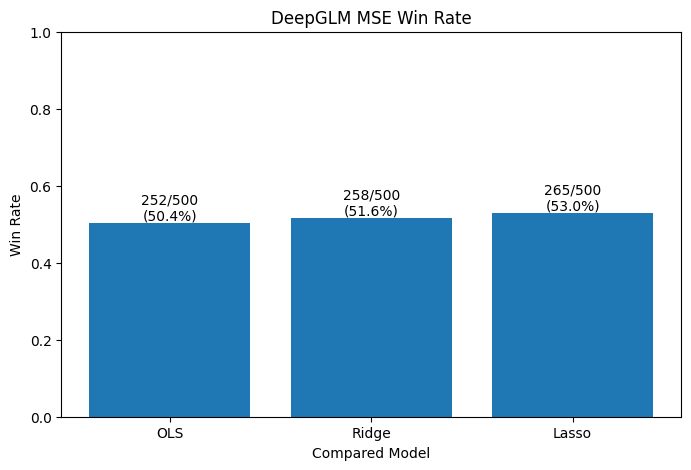

In [8]:
import matplotlib.pyplot as plt

n_sim = len(performence_results)

win_counts = {
    "OLS": (performence_results["DeepGLM_MSE"] < performence_results["OLS_MSE"]).sum(),
    "Ridge": (performence_results["DeepGLM_MSE"] < performence_results["Ridge_MSE"]).sum(),
    "Lasso": (performence_results["DeepGLM_MSE"] < performence_results["Lasso_MSE"]).sum()
}

win_rates = {model: count / n_sim for model, count in win_counts.items()}

plt.figure(figsize=(8, 5))

bars = plt.bar(win_rates.keys(), win_rates.values())

plt.xlabel("Compared Model")
plt.ylabel("Win Rate")
plt.title("DeepGLM MSE Win Rate")

plt.ylim(0, 1)

for bar, count in zip(bars, win_counts.values()):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{count}/{n_sim}\n({height:.1%})",
        ha="center",
        va="bottom"
    )

plt.show()

In [6]:
print(performence_results[
    ["OLS_MSE", "Ridge_MSE", "Lasso_MSE", "DeepGLM_MSE"]
].mean())

OLS_MSE        4.031413
Ridge_MSE      4.031314
Lasso_MSE      4.033903
DeepGLM_MSE    4.031134
dtype: float64


In [7]:
from scipy.stats import ttest_rel

models = ["OLS", "Ridge", "Lasso"]

for model in models:

    diff = (
        performence_results["DeepGLM_MSE"]
        - performence_results[f"{model}_MSE"]
    )

    result = ttest_rel(
        performence_results["DeepGLM_MSE"],
        performence_results[f"{model}_MSE"],
        alternative="less"
    )

    print(f"\nDeepGLM vs {model}")
    print(f"Mean difference = {diff.mean():.6f}")
    print(f"SD difference   = {diff.std():.6f}")
    print(f"t-statistic     = {result.statistic:.4f}")
    print(f"p-value         = {result.pvalue:.6g}")


DeepGLM vs OLS
Mean difference = -0.000279
SD difference   = 0.006029
t-statistic     = -1.0346
p-value         = 0.150668

DeepGLM vs Ridge
Mean difference = -0.000180
SD difference   = 0.003103
t-statistic     = -1.2972
p-value         = 0.0975796

DeepGLM vs Lasso
Mean difference = -0.002769
SD difference   = 0.016219
t-statistic     = -3.8173
p-value         = 7.59379e-05
